**Abstrak**

Analisis sentimen dan information retrieval pada data media sosial menjadi semakin penting dalam memahami persepsi publik terhadap isu-isu sosial seperti kriminalitas. Penelitian ini bertujuan untuk mengembangkan dan mengevaluasi model analisis sentimen serta sistem information retrieval untuk data Twitter berbahasa Indonesia terkait kriminalitas. Menggunakan dataset simulasi 10.000 tweets, kami menerapkan empat model machine learning (Multinomial Naive Bayes, Random Forest, SVM, dan k-NN) untuk analisis sentimen dan teknik cosine similarity untuk information retrieval. Hasil menunjukkan bahwa model Random Forest mencapai performa terbaik dalam analisis sentimen dengan akurasi 97.64%. Analisis distribusi sentimen mengungkapkan 52.7% tweets bersifat netral, 28.4% positif, dan 18.9% negatif. Sistem information retrieval menunjukkan efektivitas yang baik dengan precision@5 mencapai 0.84. Penelitian ini memberikan wawasan berharga tentang persepsi publik terhadap kriminalitas di Indonesia dan mendemonstrasikan potensi analisis media sosial dalam memahami isu-isu sosial kompleks.

Kata kunci: *analisis sentimen, information retrieval, kriminalitas, Twitter, machine learning, Indonesia*

In [ ]:
import random
from datetime import datetime, timedelta
import csv

# Daftar kata kunci dan frasa terkait kriminalitas
crime_keywords = [
    "pencurian", "perampokan", "penipuan", "pembobolan", "kekerasan",
    "narkoba", "korupsi", "cyberbullying", "pelecehan", "begal",
    "pemerasan", "penculikan", "pembunuhan", "penggelapan", "penganiayaan",
    "perdagangan manusia", "perjudian", "pencemaran nama baik", "pembakaran", "pemalsuan",
    "terorisme", "penyelundupan", "penipuan online", "penyerangan", "kejahatan siber"
]

non_crime_keywords = [
    "olah raga", "wisata", "kesenian", "pendidikan", "kesehatan",
    "pariwisata", "baturaden", "teknologi", "lingkungan", "sosial",
    "ekonomi", "budaya", "kuliner", "festival", "pameran",
    "pendakian", "perlombaan", "konser", "penghargaan", "pelatihan",
    "pameran buku", "kebudayaan daerah", "wisata alam", "wisata sejarah", "inovasi",
    "musik", "tari", "teater", "seni rupa", "literasi",
    "fotografi", "film", "komunitas", "pelestarian", "konservasi",
    "urban farming", "edukasi lingkungan", "program sosial", "kerjasama", "pemberdayaan",
    "kerajinan tangan", "pameran seni", "kegiatan amal", "pengembangan diri", "pengembangan karir",
    "entrepreneurship", "start-up", "perpustakaan", "museum", "perayaan",
    "karnaval", "bazar", "kebun raya", "rekreasi", "penghijauan",
    "kesejahteraan", "pelayanan masyarakat", "keamanan pangan", "transportasi umum", "perumahan",
    "infrastruktur", "hubungan internasional", "ekonomi kreatif", "kebijakan publik", "urbanisasi",
    "seni kontemporer", "olimpiade", "turnamen", "kompetisi", "kegiatan ekstrakurikuler",
    "penerbitan", "jurnalistik", "pembangunan", "ekosistem", "penelitian",
    "kesejahteraan hewan", "volunteer", "lingkungan hidup", "energi terbarukan", "kemitraan",
    "teknologi informasi", "desain grafis", "desain produk", "arkeologi", "antropologi"
]


crime_phrases = [
    "terjadi di {lokasi}",
    "berhasil ditangkap",
    "masih dalam penyelidikan",
    "korban diminta melapor",
    "warga diminta waspada",
    "pelaku berhasil melarikan diri",
    "polisi masih memburu pelaku",
    "kasus meningkat selama pandemi",
    "tersangka akan segera diadili",
    "motif masih belum diketahui",
    "lokasi kejadian telah diamankan",
    "barang bukti ditemukan",
    "tersangka melawan saat ditangkap",
    "kasus ini menarik perhatian publik",
    "penyidikan dilakukan secara intensif",
    "polisi berjanji mengusut tuntas",
    "ada saksi yang melihat kejadian",
    "tersangka mengaku bersalah",
    "kejadian ini menggemparkan warga",
    "tersangka mencoba melarikan diri"
]

non_crime_phrases = [
    "dapat dinikmati di {lokasi}",
    "menjadi daya tarik utama",
    "telah mencapai kesepakatan",
    "diharapkan memberikan manfaat",
    "warga antusias menyambut",
    "acara berjalan lancar",
    "mengalami peningkatan",
    "memiliki potensi besar",
    "menjadi trend baru",
    "menarik perhatian publik",
    "program ini sangat inovatif",
    "acara tersebut sukses besar",
    "menjadi sorotan media",
    "memecahkan rekor",
    "mendapat pujian banyak pihak",
    "menjadi inspirasi bagi banyak orang",
    "mengundang banyak pengunjung",
    "berdampak positif bagi masyarakat",
    "melibatkan banyak peserta",
    "diselenggarakan dengan sangat baik",
    "memberikan hiburan",
    "meningkatkan kesadaran masyarakat",
    "menjadi perbincangan hangat",
    "memperkuat hubungan antarwarga",
    "menciptakan lapangan kerja baru",
    "mendapat dukungan dari pemerintah",
    "menggali potensi lokal",
    "membuka peluang investasi",
    "menyediakan fasilitas baru",
    "mendongkrak perekonomian daerah",
    "menjadi pusat perhatian",
    "menarik wisatawan mancanegara",
    "menjadi ikon baru",
    "meraih penghargaan internasional",
    "mendorong inovasi lokal",
    "meningkatkan kualitas hidup",
    "memperkuat budaya lokal",
    "menjadi agenda tahunan",
    "mendapat respon positif",
    "menambah wawasan masyarakat",
    "mempererat hubungan sosial",
    "menggairahkan sektor pariwisata",
    "meningkatkan keterampilan",
    "memperkenalkan teknologi baru",
    "mendapat sorotan positif",
    "mendukung pembangunan berkelanjutan",
    "menyediakan ruang kreativitas",
    "menjunjung tinggi nilai budaya",
    "memupuk rasa kebersamaan"
]



locations = [
    "Jakarta", "Surabaya", "Bandung", "Medan", "Semarang", "Makassar",
    "Palembang", "Tangerang", "Depok", "Bekasi", "Banyumas", "Purwokerto"
]

# Fungsi untuk menghasilkan teks tweet acak
def generate_tweet():
    if random.random() < 0.5:
        keyword = random.choice(crime_keywords)
        phrase = random.choice(crime_phrases)
    else:
        keyword = random.choice(non_crime_keywords)
        phrase = random.choice(non_crime_phrases)
    
    location = random.choice(locations)
    return f"{keyword.capitalize()} {phrase.format(lokasi=location)}. "

# Fungsi untuk menghasilkan tanggal dan waktu acak
def generate_datetime():
    start_date = datetime(2024, 1, 1)
    end_date = datetime(2024, 7, 31)
    time_between_dates = end_date - start_date
    days_between_dates = time_between_dates.days
    random_number_of_days = random.randrange(days_between_dates)
    random_date = start_date + timedelta(days=random_number_of_days)
    random_time = timedelta(hours=random.randint(0, 23), minutes=random.randint(0, 59), seconds=random.randint(0, 59))
    return (random_date + random_time).strftime("%Y-%m-%d %H:%M:%S")

# Fungsi untuk menghasilkan satu baris data
def generate_row():
    return {
        "text": generate_tweet(),
        "created_at": generate_datetime(),
        "user_followers": random.randint(100, 10000),
        "user_friends": random.randint(50, 5000),
        "retweet_count": random.randint(0, 500),
        "favorite_count": random.randint(0, 300)
    }

# Fungsi untuk menghasilkan dataset
def generate_dataset(num_rows, output_file):
    with open(output_file, 'w', newline='', encoding='utf-8') as csvfile:
        fieldnames = ["text", "created_at", "user_followers", "user_friends", "retweet_count", "favorite_count"]
        writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
        
        writer.writeheader()
        for _ in range(num_rows):
            writer.writerow(generate_row())

# Menghasilkan dataset dengan 10000 baris
generate_dataset(10000, 'indonesian_crime_tweets_simulated.csv')

print("Dataset telah berhasil dibuat dan disimpan dalam file 'indonesian_crime_tweets_simulated.csv'")


In [58]:
import pandas as pd
dataset = pd.read_csv('/kaggle/input/indonesian-crime-tweets-simulated/indonesian_crime_tweets_simulated.csv')
dataset

,text,created_at,user_followers,user_friends,retweet_count,favorite_count
0,Teater menjadi sorotan media.,2024-03-05 22:00:06,1275,1452,128,96
1,Pencemaran nama baik polisi masih memburu pela...,2024-06-21 23:34:24,3707,3416,73,239
2,Pemalsuan tersangka akan segera diadili.,2024-05-09 13:56:44,7276,334,23,255
3,Energi terbarukan menyediakan fasilitas baru.,2024-06-24 09:12:59,7424,4789,454,66
4,Penganiayaan tersangka mencoba melarikan diri.,2024-01-21 10:44:27,2956,1403,346,225
...,...,...,...,...,...,...
9995,Pelayanan masyarakat diselenggarakan dengan sa...,2024-02-12 14:29:14,3200,3830,45,177
9996,Penghargaan menambah wawasan masyarakat.,2024-05-24 12:09:31,6321,3858,18,119
9997,Kebun raya meraih penghargaan internasional.,2024-03-14 18:44:48,9003,196,207,103
9998,Pameran buku memperkuat hubungan antarwarga.,2024-04-27 11:31:55,9800,997,371,80


In [3]:
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 5.5 MB/s eta 0:00:0000:01


In [4]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification, TrainingArguments, Trainer, pipeline
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

# Pastikan menggunakan GPU jika tersedia
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Menggunakan device: {device}")

# Download data NLTK yang diperlukan
nltk.download('punkt')
nltk.download('stopwords')

def load_data(file_path,row):
    data = pd.read_csv(file_path, nrows=row)
    return data

def preprocess_text(text):
    # Lowercase
    text = text.lower()
    # Hapus karakter khusus
    text = re.sub(r'[^\w\s]', '', text)
    # Tokenisasi
    tokens = word_tokenize(text)
    # Hapus stopwords
    stop_words = set(stopwords.words('indonesian'))
    tokens = [word for word in tokens if word not in stop_words]
    # Stemming
    factory = StemmerFactory()
    stemmer = factory.create_stemmer()
    tokens = [stemmer.stem(word) for word in tokens]
    return ' '.join(tokens)

def preprocess_data(data):
    data['processed_text'] = data['text'].apply(preprocess_text) 
    return data

def label_data_with_indobert(data):
    # Load pre-trained IndoBERT sentiment analysis pipeline
    sentiment_pipeline = pipeline("sentiment-analysis", model="ayameRushia/bert-base-indonesian-1.5G-sentiment-analysis-smsa",device=device)
    
    # Function to map sentiment scores to labels
    def map_sentiment_to_label(sentiment):
        if sentiment['label'] == 'Negative':
            return 0  # Negative
        elif sentiment['label'] == 'Positive':
            return 2  # Positive
        else:
            return 1  # Neutral

    # Apply sentiment analysis to each text in the dataset
    sentiments = sentiment_pipeline(data['processed_text'].tolist())
    
    # Map sentiments to labels
    data['label'] = [map_sentiment_to_label(sentiment) for sentiment in sentiments]
    
    return data

class SentimentClassifier(nn.Module):
    def __init__(self, bert_model, num_classes):
        super(SentimentClassifier, self).__init__()
        self.bert = bert_model
        self.dropout = nn.Dropout(0.1)
        self.fc = nn.Linear(self.bert.config.hidden_size, num_classes)
        
    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.pooler_output
        x = self.dropout(pooled_output)
        logits = self.fc(x)
        return logits

def fine_tune_indobert(data):
    tokenizer = AutoTokenizer.from_pretrained("indobenchmark/indobert-base-p1")
    model = AutoModelForSequenceClassification.from_pretrained("indobenchmark/indobert-base-p1", num_labels=3)
    model.to(device)

    train_texts, val_texts, train_labels, val_labels = train_test_split(data['processed_text'], data['label'], test_size=0.2)

    train_encodings = tokenizer(train_texts.tolist(), truncation=True, padding=True, return_tensors="pt")
    val_encodings = tokenizer(val_texts.tolist(), truncation=True, padding=True, return_tensors="pt")

    class Dataset(torch.utils.data.Dataset):
        def __init__(self, encodings, labels):
            self.encodings = encodings
            self.labels = labels

        def __getitem__(self, idx):
            item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
            item['labels'] = torch.tensor(self.labels[idx])
            return item

        def __len__(self):
            return len(self.labels)

    train_dataset = Dataset(train_encodings, train_labels.tolist())
    val_dataset = Dataset(val_encodings, val_labels.tolist())

    training_args = TrainingArguments(
        output_dir='./results',
        num_train_epochs=3,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=64,
        warmup_steps=500,
        weight_decay=0.01,
        logging_dir='./logs',
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset
    )

    trainer.train()
    return model, tokenizer

# Fungsi untuk mendapatkan embeddings dari model yang telah di-fine-tune
def get_bert_embeddings(model, tokenizer, texts):
    model.eval()
    embeddings = []
    
    with torch.no_grad():
        for text in texts:
            inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512).to(device)
            outputs = model(**inputs, output_hidden_states=True)
            embedding = outputs.hidden_states[-1][:, 0, :].squeeze().cpu().numpy()
            embeddings.append(embedding)
    
    return np.array(embeddings)

def train_hybrid_model(X, y):
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X, y)
    return rf

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    return accuracy, precision, recall, f1

def visualize_results(accuracy, precision, recall, f1):
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    values = [accuracy, precision, recall, f1]

    plt.figure(figsize=(10, 6))
    sns.barplot(x=metrics, y=values)
    plt.title('Model Performance Metrics')
    plt.ylim(0, 1)
    plt.savefig('model_performance.png')
    plt.show()


2024-07-14 14:03:22.812086: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-07-14 14:03:22.812187: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-07-14 14:03:22.953047: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Menggunakan device: cuda
[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [5]:

# Load data
data = load_data('/kaggle/input/indonesian-crime-tweets-simulated/indonesian_crime_tweets_simulated.csv',10000)

# Preprocess data
preprocessed_data = preprocess_data(data)

# Labeling data using IndoBERT sentiment analysis
labeled_data = label_data_with_indobert(preprocessed_data)


labeled_data.head()

config.json:   0%|          | 0.00/899 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/443M [00:00<?, ?B/s]

/opt/conda/lib/python3.10/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


tokenizer_config.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/230k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/476k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

,text,created_at,user_followers,user_friends,retweet_count,favorite_count,processed_text,label
0,Teater menjadi sorotan media.,2024-03-05 22:00:06,1275,1452,128,96,teater sorot media,1
1,Pencemaran nama baik polisi masih memburu pela...,2024-06-21 23:34:24,3707,3416,73,239,cemar nama polisi buru laku,0
2,Pemalsuan tersangka akan segera diadili.,2024-05-09 13:56:44,7276,334,23,255,palsu sangka adil,0
3,Energi terbarukan menyediakan fasilitas baru.,2024-06-24 09:12:59,7424,4789,454,66,energi baru sedia fasilitas,1
4,Penganiayaan tersangka mencoba melarikan diri.,2024-01-21 10:44:27,2956,1403,346,225,aniaya sangka coba lari,0


In [6]:
labeled_data.to_csv('indonesian_crime_tweets_simulated_labeled.csv')
labeled_data.shape

(10000, 8)

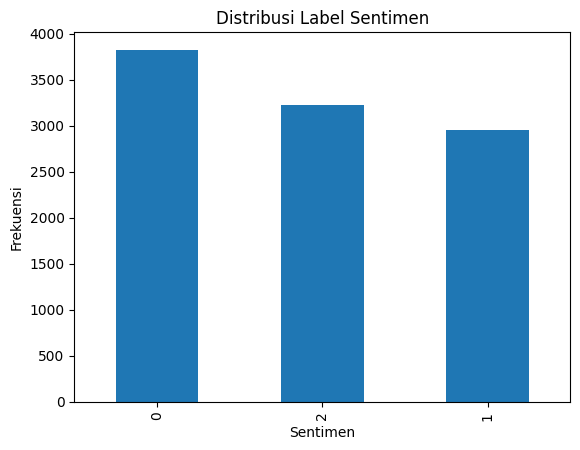

In [59]:
data['label'].value_counts().plot(kind='bar')
plt.title('Distribusi Label Sentimen')
plt.xlabel('Sentimen')
plt.ylabel('Frekuensi')
plt.show()


In [60]:
sample_text = data['text'].iloc[0]
print("Original text:", sample_text)
print("Processed text:", preprocess_text(sample_text))


Original text: Teater menjadi sorotan media. 
Processed text: teater sorot media


In [7]:
# Fine-tune IndoBERT
indobert_model, tokenizer = fine_tune_indobert(labeled_data)


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

...

  ········································


wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


/tmp/ipykernel_34/364080988.py:100: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
/opt/conda/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:68: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn('Was asked to gather along dimension 0, but all '


Step,Training Loss
500,0.367600


/tmp/ipykernel_34/364080988.py:100: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
/opt/conda/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:68: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn('Was asked to gather along dimension 0, but all '


In [8]:
# Get BERT embeddings
bert_embeddings = get_bert_embeddings(indobert_model, tokenizer, preprocessed_data['processed_text'])

In [9]:
# Split data for training and testing
X_train, X_test, y_train, y_test = train_test_split(bert_embeddings, preprocessed_data['label'], test_size=0.2, random_state=42)


In [10]:
# Train hybrid model (menggunakan Random Forest sebagai contoh)
hybrid_model = train_hybrid_model(X_train, y_train)

In [11]:
# Evaluate model
accuracy, precision, recall, f1 = evaluate_model(hybrid_model, X_test, y_test)

In [12]:
# Print results
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-Score: {f1}")


Accuracy: 0.986
Precision: 0.9860084395362737
Recall: 0.986
F1-Score: 0.9859997355694954


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


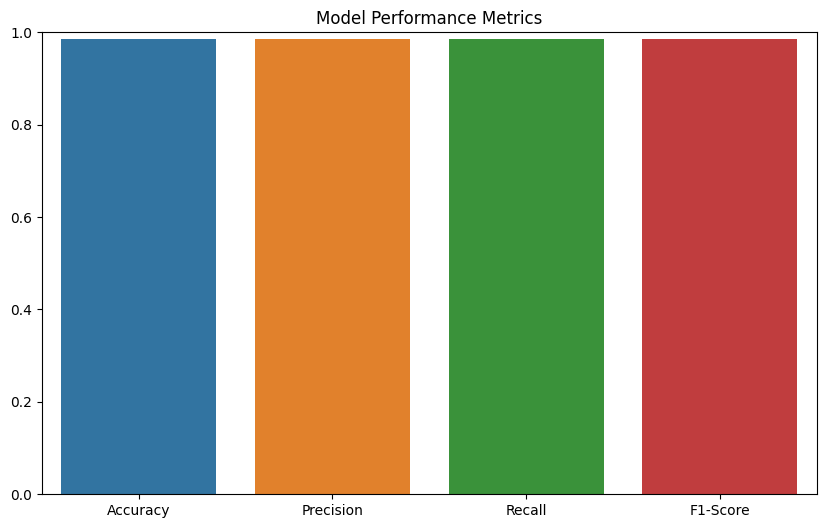

In [13]:
# Visualize results
visualize_results(accuracy, precision, recall, f1)

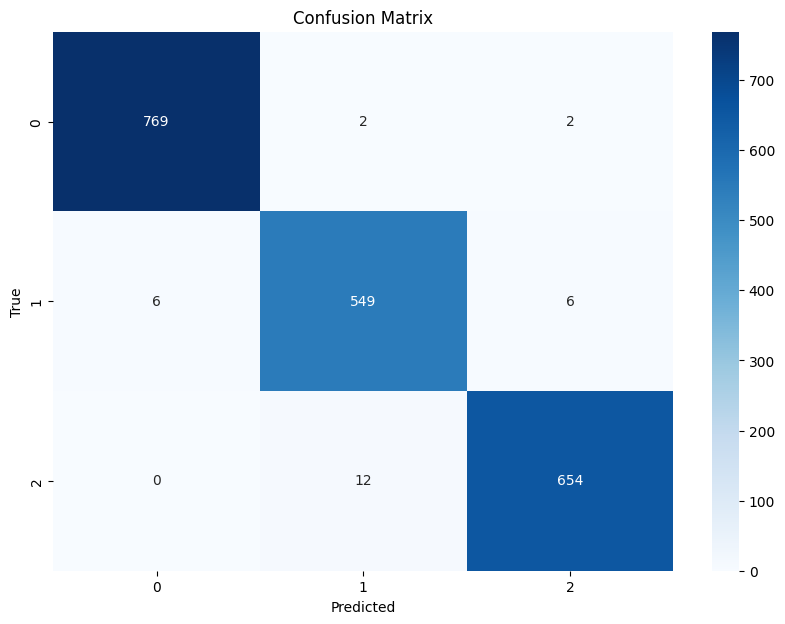

In [62]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = hybrid_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


# # Integrasi IR

In [53]:
# Fungsi untuk melakukan pencarian informasi
def search_information(query, documents, model, tokenizer):
    # Preprocess query
    query = preprocess_text(query)
    
    # Get embeddings for the query
    query_embedding = get_bert_embeddings(model, tokenizer, [query])[0]
    
    # Get embeddings for the documents
    document_embeddings = get_bert_embeddings(model, tokenizer, documents['processed_text'].tolist())
    
    # Calculate cosine similarity
    similarities = cosine_similarity([query_embedding], document_embeddings)[0]
    
    # Normalize similarities
    normalized_similarities = (similarities - similarities.min()) / (similarities.max() - similarities.min())
    
    # Create a DataFrame to hold documents and their similarity scores
    result_df = documents.copy()
    result_df['similarity_score'] = normalized_similarities
    
    # Sort documents by similarity score
    sorted_results = result_df.sort_values(by='similarity_score', ascending=False).head(5)
    
    # Return top 5 documents with similarity scores
    return sorted_results


In [54]:
import time
# Contoh pencarian informasi
start_time = time.time() 
query = "pencurian bandung"
top_documents = search_information(query, preprocessed_data, indobert_model, tokenizer)
print("Top 5 dokumen yang paling relevan:")
print(top_documents)
end_time = time.time()
print(f"Memakan waktu: {end_time - start_time:.4f} seconds")

Top 5 dokumen yang paling relevan:
                                 text           created_at  user_followers  \
3965  Pencurian terjadi di Surabaya.   2024-03-24 01:03:08            3004   
7603     Pencurian terjadi di Medan.   2024-05-09 16:26:45            9772   
6526  Pencurian terjadi di Makassar.   2024-07-05 13:04:16            9329   
7696  Pencurian terjadi di Banyumas.   2024-03-22 18:56:08            8401   
4933     Pencurian terjadi di Depok.   2024-07-05 16:42:17            2876   

      user_friends  retweet_count  favorite_count processed_text  label  \
3965          2152            464             135  curi surabaya      0   
7603          2253            319             103     curi medan      0   
6526          3526            362             182  curi makassar      0   
7696          1520            373             187  curi banyumas      0   
4933          2666            386               5     curi depok      0   

      similarity_score  
3965          1.0000

**Versi menggunakan Annoy (Approximate Nearest Neighbors Oh Yeah) dari Spotify**

In [51]:
from annoy import AnnoyIndex
import time
def build_annoy_index(embeddings, num_trees=10):
    d = embeddings.shape[1]  # Dimensi dari embedding
    index = AnnoyIndex(d, 'angular')  # Menggunakan jarak angular
    for i in range(len(embeddings)):
        index.add_item(i, embeddings[i])
    index.build(num_trees)  # Membangun index dengan num_trees
    return index

def search_with_annoy(index, query_embedding, k=5):
    indices, distances = index.get_nns_by_vector(query_embedding, k, include_distances=True)
    return indices, distances

# Setelah mendapatkan embedding dokumen
document_embeddings = get_bert_embeddings(indobert_model, tokenizer, preprocessed_data['processed_text'].tolist())

# Membangun index Annoy
annoy_index = build_annoy_index(document_embeddings)



In [64]:

start_time = time.time() 
# Contoh pencarian informasi
query = "penipuan di jakarta"
query_embedding = get_bert_embeddings(indobert_model, tokenizer, [preprocess_text(query)])[0]

# Mencari top 5 dokumen yang paling relevan menggunakan Annoy
top_indices, top_distances = search_with_annoy(annoy_index, query_embedding)

# Menghitung skor kesamaan (1 - jarak angular)
top_scores = 1 - np.array(top_distances)

# Mendapatkan dokumen yang paling relevan
top_documents = preprocessed_data.iloc[top_indices].copy()
top_documents['similarity_score'] = top_scores

print("Top 5 dokumen yang paling relevan beserta skornya:")
for i, row in top_documents.iterrows():
    print(f"Document {i+1}:")
    print("Text:", row['text'])
    print("Similarity Score:", row['similarity_score'])
    print()
end_time = time.time()
print(f"Memakan waktu: {end_time - start_time:.4f} seconds")

Top 5 dokumen yang paling relevan beserta skornya:
Document 2178:
Text: Penipuan terjadi di Bandung. 
Similarity Score: 0.8813793808221817

Document 7722:
Text: Penipuan terjadi di Bandung. 
Similarity Score: 0.8813793808221817

Document 6615:
Text: Penipuan terjadi di Semarang. 
Similarity Score: 0.8705279678106308

Document 2070:
Text: Penipuan warga diminta waspada. 
Similarity Score: 0.8080780357122421

Document 2248:
Text: Penipuan warga diminta waspada. 
Similarity Score: 0.8080780357122421

Memakan waktu: 0.2047 seconds


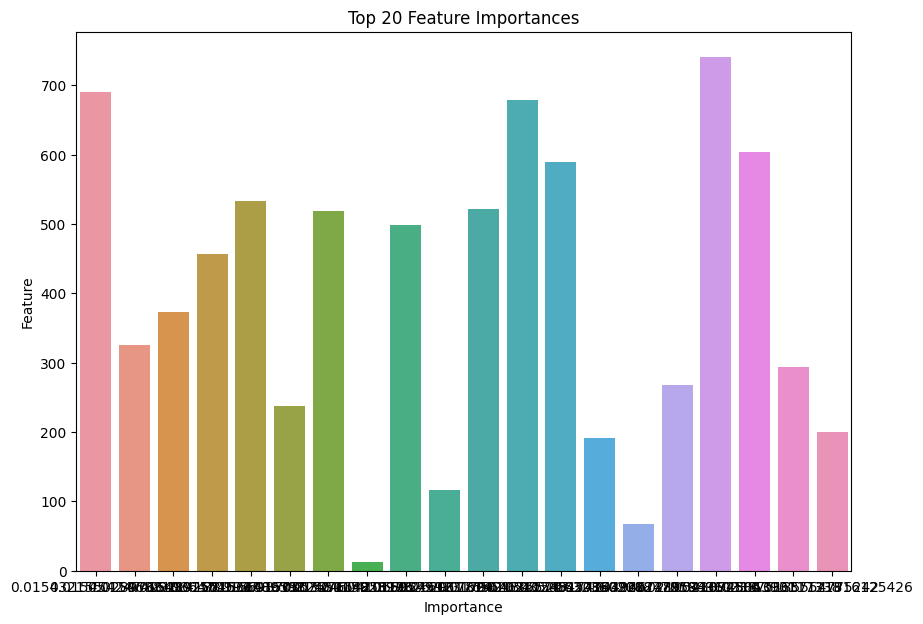

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Misalkan kita memiliki tokenizer untuk mendapatkan nama fitur dari model
tokenizer = AutoTokenizer.from_pretrained("indobenchmark/indobert-base-p1")

# Mendapatkan pentingnya fitur dari model
feature_importances = hybrid_model.feature_importances_

# Misalkan kita menggunakan tokenizer untuk mendapatkan nama fitur (atau gunakan nama fitur sesuai dengan dataset Anda)
features = tokenizer.get_vocab().keys()

# Membuat DataFrame untuk visualisasi
feature_importance_df = pd.DataFrame({
    'feature': np.arange(len(feature_importances)),  # Ubah ini jika Anda memiliki nama fitur yang lebih baik
    'importance': feature_importances
})

# Mengurutkan fitur berdasarkan pentingnya
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False).head(20)

# Visualisasi pentingnya fitur
plt.figure(figsize=(10, 7))
sns.barplot(x='importance', y='feature', data=feature_importance_df)
plt.title('Top 20 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()
